The following notebook contains broad data cleaning and analysis of the [https://www.kaggle.com/competitions/home-credit-default-risk/overview](https://www.kaggle.com/competitions/home-credit-default-risk/overview) dataset.

# Dataset structure

The dataset is made of 10 tables, 346 columns, and a total of 2.68GB of data. Due to simple volume of information, data cleaning is going to be partitioned on table by table basis.


The tables have following structure and [description](https://www.kaggle.com/competitions/home-credit-default-risk/data):

![Dataset Structure](images/dataset_structure.png)




### Table descriptions:

- **application_{train|test}.csv**  
    - This is the main table, broken into two files for Train (with TARGET) and Test (without TARGET).  
    - Static data for all applications. One row represents one loan in our data sample.

- **bureau.csv**  
    - All client's previous credits provided by other financial institutions that were reported to Credit Bureau (for clients who have a loan in our sample).  
    - For every loan in our sample, there are as many rows as number of credits the client had in Credit Bureau before the application date.

- **bureau_balance.csv**  
    - Monthly balances of previous credits in Credit Bureau.  
    - This table has one row for each month of history of every previous credit reported to Credit Bureau – i.e the table has (#loans in sample * # of relative previous credits * # of months where we have some history observable for the previous credits) rows.

- **POS_CASH_balance.csv**  
    - Monthly balance snapshots of previous POS (point of sales) and cash loans that the applicant had with Home Credit.  
    - This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credits * # of months in which we have some history observable for the previous credits) rows.

- **credit_card_balance.csv**  
    - Monthly balance snapshots of previous credit cards that the applicant has with Home Credit.  
    - This table has one row for each month of history of every previous credit in Home Credit (consumer credit and cash loans) related to loans in our sample – i.e. the table has (#loans in sample * # of relative previous credit cards * # of months where we have some history observable for the previous credit card) rows.

- **previous_application.csv**  
    - All previous applications for Home Credit loans of clients who have loans in our sample.  
    - There is one row for each previous application related to loans in our data sample.

- **installments_payments.csv**  
    - Repayment history for the previously disbursed credits in Home Credit related to the loans in our sample.  
    - There is a) one row for every payment that was made plus b) one row each for missed payment.  
    - One row is equivalent to one payment of one installment OR one installment corresponding to one payment of one previous Home Credit credit related to loans in our sample.

- **HomeCredit_columns_description.csv**  
    - This file contains descriptions for the columns in the various data files.

#### Considerations
One obvious goal emerges - given the train/test dataset, we would want to build a predictive model that would determine someone defaulting on a loan. Given tables with more than one entry per person, we will likely want to build intermediary models that will predict other valuable information and act as features for our final model.

# Imports

In [ ]:
import os
import pandas as pd
from helpers.utils.cleaner_helper import plot_numeric_dist, plot_categorical_dist
from helpers.utils import plotting_helper
from helpers import table_navigator
import pickle as pkl
import importlib


pd.set_option('display.max_colwidth', 2)

# Table Analysis

We first load all the tables and check their data information. The table needs to be loaded in `windows-1252` to avoid a read error at the table descriptions line 200 `Was the previous application for CASH, POS, CAR, �`.

In [2]:
tables = table_navigator.get_tables_from_dir('data/raw_csv')

Loading tables: ['application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv']
loaded application_test with shape (48744, 121)


loaded application_train with shape (307511, 122)
loaded bureau with shape (1716428, 17)
loaded bureau_balance with shape (27299925, 3)
loaded credit_card_balance with shape (3840312, 23)
loaded HomeCredit_columns_description with shape (219, 5)
loaded installments_payments with shape (13605401, 8)
loaded POS_CASH_balance with shape (10001358, 8)
loaded previous_application with shape (1670214, 37)
loaded sample_submission with shape (48744, 2)


We can see that the application test and application shape tables are much wider than others - other tables provide supplementary information that could be used for further analysis.

In [ ]:
tables = table_navigator.get_tables_from_dir("data/raw_csv", ['application_train', 'HomeCredit_columns_description', 'application_test'])

Loading tables: ['application_test.csv', 'application_train.csv', 'HomeCredit_columns_description.csv']
loaded application_test with shape (48744, 121)
loaded application_train with shape (307511, 122)
loaded HomeCredit_columns_description with shape (219, 5)


# HomeCredit_columns_description
We start our analysis with a descriptor table, which provides context and understanding into other columns. Without this context, a manual analysis of values or EDA makes very little sense.

In [4]:
descriptions = tables['HomeCredit_columns_description']
if 'Unnamed: 0' in descriptions.columns:
    print("Dropping 'Unnamed: 0' column from descriptions")
    descriptions.drop(columns=['Unnamed: 0'], inplace=True)

descriptions

Dropping 'Unnamed: 0' column from descriptions


,Table,Row,Description,Special
0,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,application_{train|test}.csv,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",NaN
2,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN
...,...,...,...,...
214,installments_payments.csv,NUM_INSTALMENT_NUMBER,On which installment we observe payment,NaN
215,installments_payments.csv,DAYS_INSTALMENT,When the installment of previous credit was supposed to be paid (relative to application date of current loan),time only relative to the application
216,installments_payments.csv,DAYS_ENTRY_PAYMENT,When was the installments of previous credit paid actually (relative to application date of current loan),time only relative to the application
217,installments_payments.csv,AMT_INSTALMENT,What was the prescribed installment amount of previous credit on this installment,NaN


In [5]:
descriptions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Table        219 non-null    object
 1   Row          219 non-null    object
 2   Description  219 non-null    object
 3   Special      86 non-null     object
dtypes: object(4)
memory usage: 7.0+ KB


The descriptions table consists of 219 unique entries. Nan Values are only found besides special comments, lack of which is possible.

#### ColumnDescriber

We then implement a custom class, which will highly simplify investigating various columns for data cleaning.
It provides information on columns:
* Source table
* Description
* Presence of special information
* Number of nan values
* Number of unique values
* Data type
* And a few sample values


In [6]:

describer = table_navigator.ColumnDescriber(tables)
describer.describe("SK_ID_CURR")


from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
0,SK_ID_CURR,ID of loan in our sample,NaN,0,307511,int64,"[100002, 100003, 100004]"


From the get got, we see that although customer ID is shared between all tables, not each instance of application has that kind of information.

# Application Table
We first look into the data stored in application table:

In [7]:
application =tables['application_train']
describer = table_navigator.ColumnDescriber(tables, 'application_train')
display(application.shape)
expected_values = application.shape[0]

(307511, 122)

The table contains a significant ammount of columns which will need to be investigated separately. The information on column contents will be taken from HomeCredit_columns_description file.

The number of rows is too large to be investigated as a whole, consequently, they will e divided into meaningful groups and investiated thus.

## Column group analysis

In [8]:
application_columns = {}
non_feature_columns = set()
cat_columns =set()
num_columns = set()
bool_columns = set()
str_columns = set()


### core identifiers

In [9]:
core_identification = [
    'SK_ID_CURR',
    'TARGET'
]

application_columns['core_identification'] = core_identification
bool_columns.add('TARGET')

non_feature_columns.add('SK_ID_CURR')

describer.describe(core_identification)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
0,SK_ID_CURR,ID of loan in our sample,NaN,0,307511,int64,"[100002, 100003, 100004]"
1,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",NaN,0,2,int64,"[1, 0]"


* Core identification columns are shared between tables. 
* Each ID value is unique.

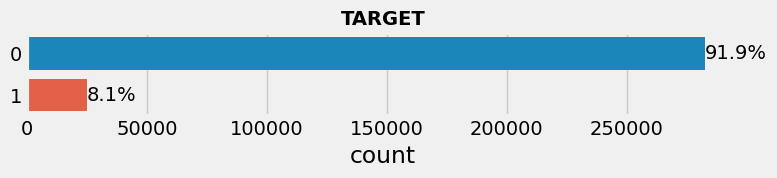

TARGET
0    282686
1    24825 
Name: count, dtype: int64

In [10]:

plot_categorical_dist(
    application,'TARGET',"TARGET")

We see that our target variable is highly imbalanced. Consequently, **Accuracy becomes near meningless**. Weighted metrics, such as **f1_macro, Precision-Recall curve** will need to be used when training the model.

#### basic loan information

In [11]:
loan_basics = [
    'NAME_CONTRACT_TYPE',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE'
]
application_columns['loan_basics'] = loan_basics
cat_columns.add('NAME_CONTRACT_TYPE')
num_columns.update(['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE'])


describer.describe(loan_basics)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN,0,2,object,"[Cash loans, Revolving loans]"
8,AMT_CREDIT,Credit amount of the loan,NaN,0,5603,float64,"[406597.5, 1293502.5, 135000.0]"
9,AMT_ANNUITY,Loan annuity,NaN,12,13672,float64,"[24700.5, 35698.5, 6750.0]"
10,AMT_GOODS_PRICE,For consumer loans it is the price of the goods for which the loan is given,NaN,278,1002,float64,"[351000.0, 1129500.0, 135000.0]"


* all loans are either cash or revolving and are known amount.
* Few values are abset for loan annuity and price of the house.

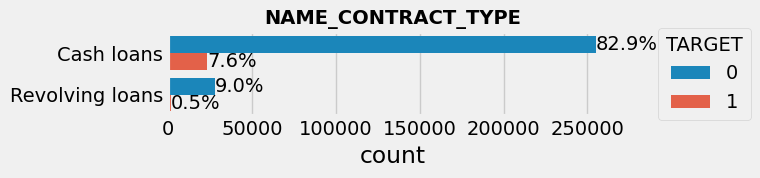

!Servere outliers detected. Total values: 307511 original range: 45000.0 - 4050000.0
Hiding outliers above 3172500.0: 20 values;


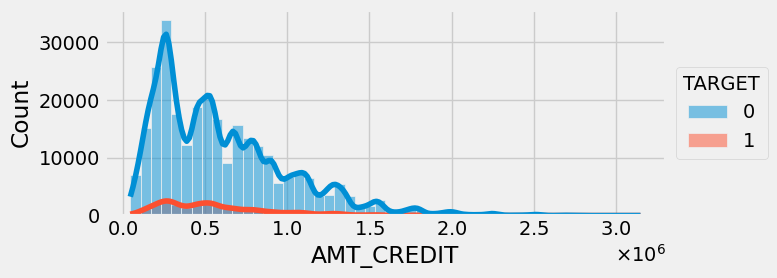

!Servere outliers detected. Total values: 307511 original range: 1615.5 - 258025.5
Hiding outliers above 119812.5: 200 values;


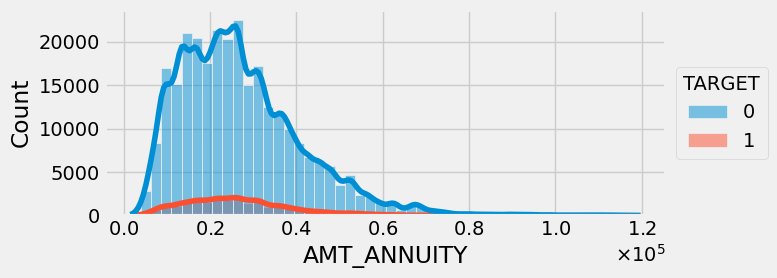

!Servere outliers detected. Total values: 307511 original range: 40500.0 - 4050000.0
Hiding outliers above 3060000.0: 29 values;


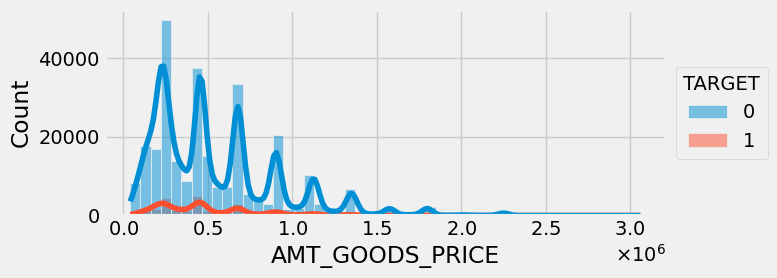

In [12]:

plot_categorical_dist(
    application,'NAME_CONTRACT_TYPE', hue="TARGET")

for col in ['AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']:
    plot_numeric_dist(
        application,col, hue ="TARGET")


* Revolving loans are a minority.
* Credit goes up to 1 million.
* The distributions are right skewed and, incase of goods price, partially discrete.

In [13]:
application[loan_basics].describe()

,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
count,3.075110e+05,307499.000000,3.072330e+05
mean,5.990260e+05,27108.573909,5.383962e+05
std,4.024908e+05,14493.737315,3.694465e+05
min,4.500000e+04,1615.500000,4.050000e+04
25%,2.700000e+05,16524.000000,2.385000e+05
50%,5.135310e+05,24903.000000,4.500000e+05
75%,8.086500e+05,34596.000000,6.795000e+05
max,4.050000e+06,258025.500000,4.050000e+06


* Houses cost from hundreds of thousands to millions.
* People oft loan almost all gouse price.
* Extreme values are simply expensive houses.

#### Financial info

In [14]:
financial_info = [
    'AMT_INCOME_TOTAL',
    'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE'
]

application_columns['financial_info'] = financial_info
cat_columns.update(['NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE'])
num_columns.add('AMT_INCOME_TOTAL')

describer.describe(financial_info)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
7,AMT_INCOME_TOTAL,Income of the client,NaN,0,2548,float64,"[202500.0, 270000.0, 67500.0]"
12,NAME_INCOME_TYPE,"Clients income type (businessman, working, maternity leave,ï¿½)",NaN,0,8,object,"[Working, State servant, Commercial associate]"
28,OCCUPATION_TYPE,What kind of occupation does the client have,NaN,96391,18,object,"[Laborers, Core staff, Accountants]"
40,ORGANIZATION_TYPE,Type of organization where client works,NaN,0,58,object,"[Business Entity Type 3, School, Government]"


* Income and income type of client is always known.
* Icome is stored at steps of 2500 dollars a year.
* Clients occupation type if often unknown.

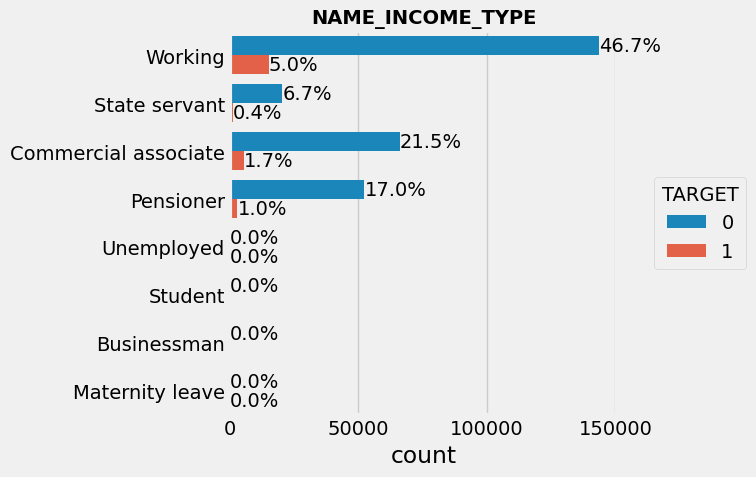

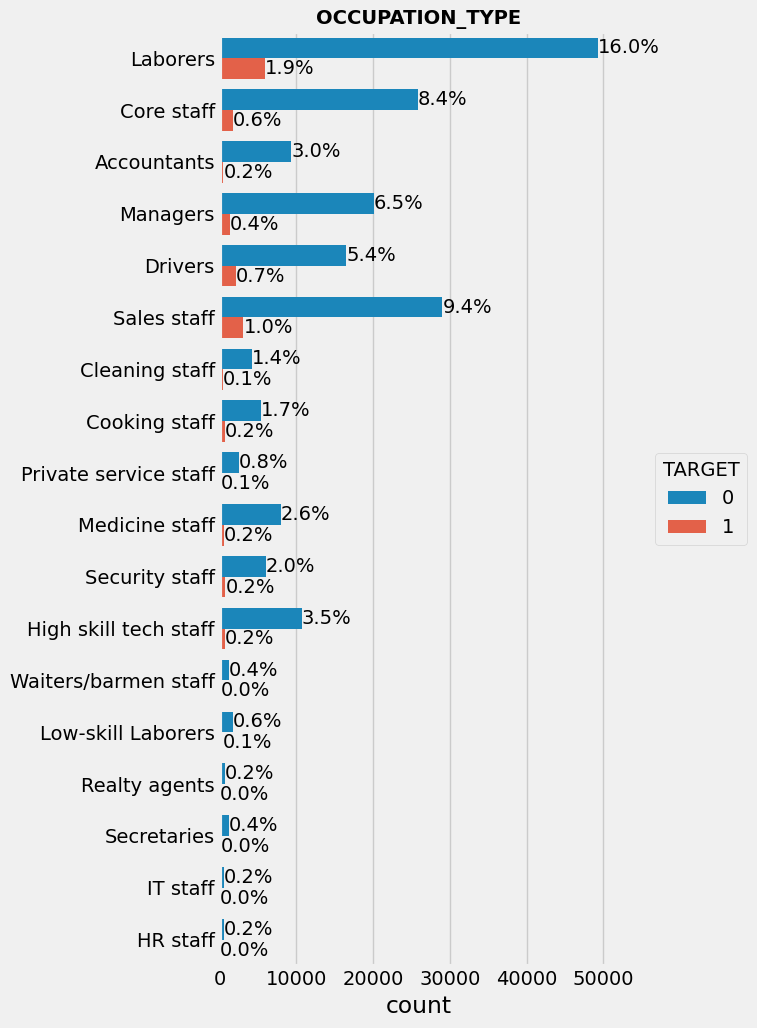

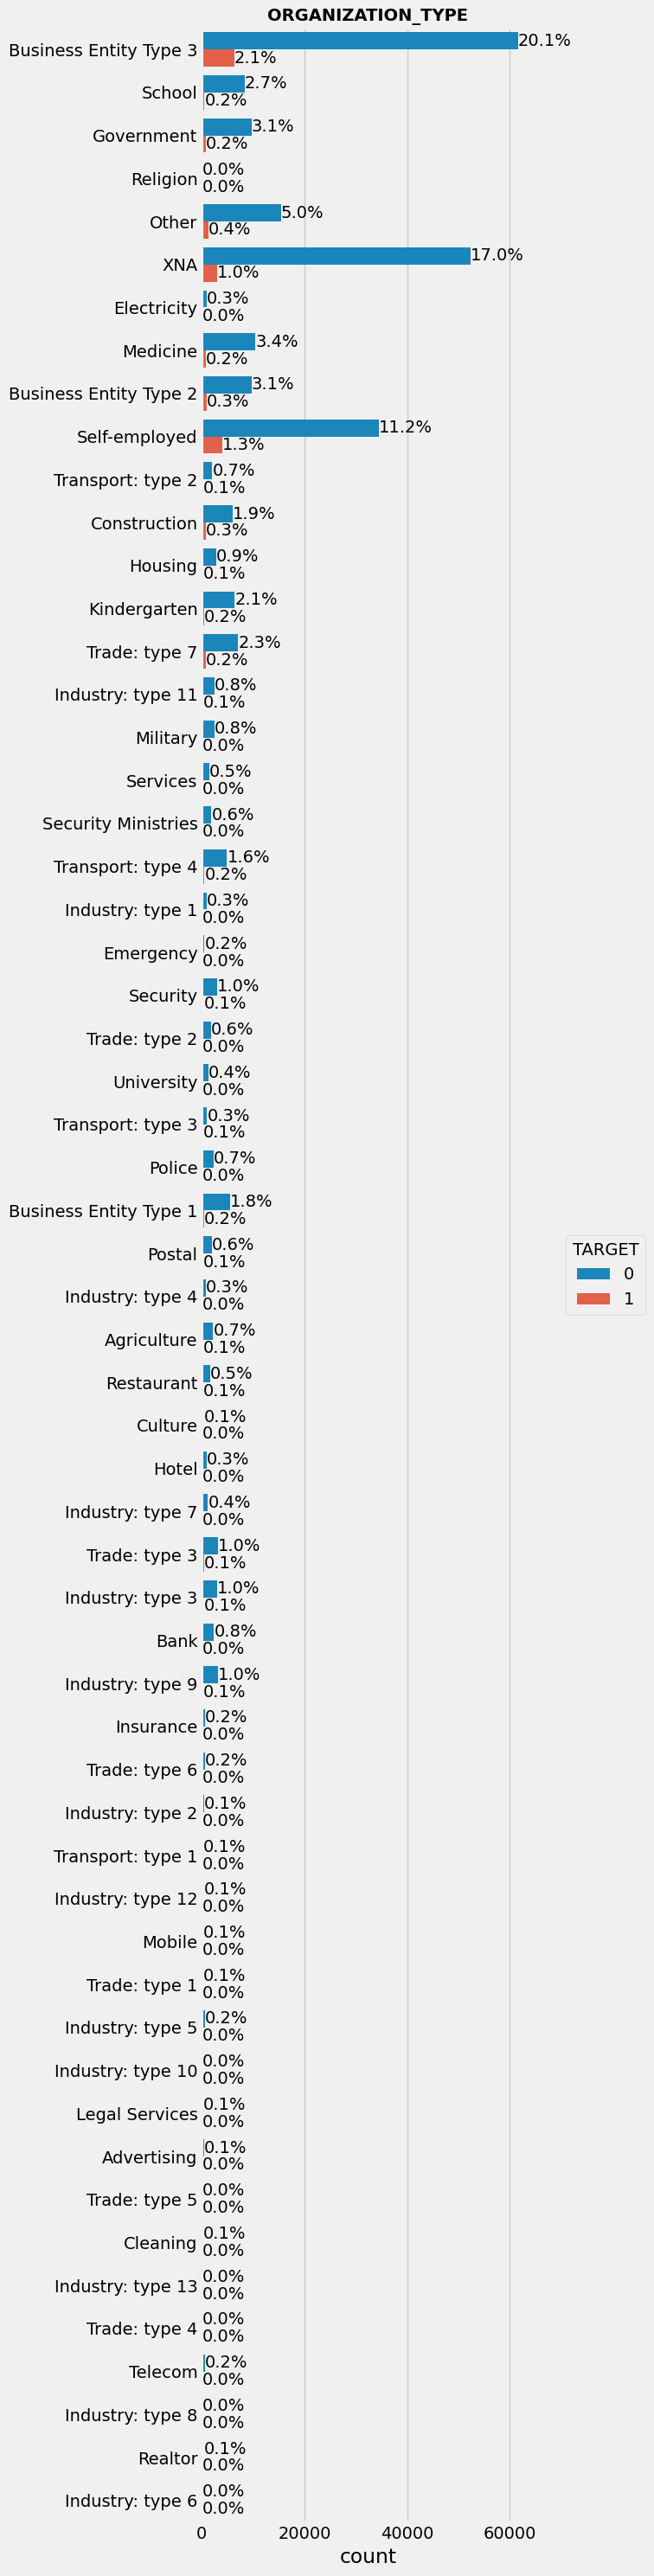

In [15]:
for col in ['NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']:
    plot_categorical_dist(
        application, col, hue="TARGET")

In [16]:
income_types_with_occupation = (
    application
    .loc[application["OCCUPATION_TYPE"].isna()]
    .groupby("NAME_INCOME_TYPE")
    .count()["AMT_INCOME_TOTAL"]
    .sort_values(ascending=False)
)
print(income_types_with_occupation)

NAME_INCOME_TYPE
Pensioner               55357
Working                 24920
Commercial associate    12297
State servant           3787 
Unemployed              22   
Student                 5    
Businessman             2    
Maternity leave         1    
Name: AMT_INCOME_TOTAL, dtype: int64


Majority of people whose profession is not known are pensioners, but other groups are included. Consequently, the missing values could be a myriad of various reasons. Most likely is clients not maching one of the neat categories and thus not being classified. **If this can be confirmed, they should be assigned as "other".**

!Servere outliers detected. Total values: 307511 original range: 25650.0 - 117000000.0
Hiding outliers above 742500.0: 646 values;


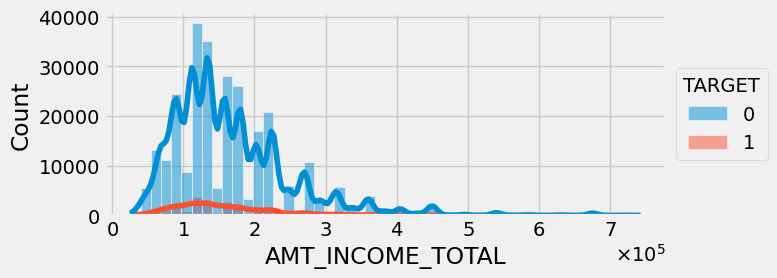

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [17]:
plot_numeric_dist(
    application, 'AMT_INCOME_TOTAL', hue="TARGET")
application['AMT_INCOME_TOTAL'].describe()

The distribution is significantly right skewed by extreme earners.
* **An outlier insensitive ML model should be used**
* **Otherwise the outlier needs to be treated**

WE thus investigate the distribution after removal of top 4% highest earners.

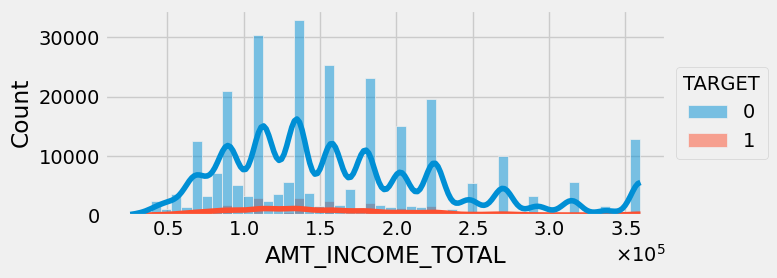

count    307511.000000
mean     163638.695826
std      75820.891913 
min      25650.000000 
25%      112500.000000
50%      147150.000000
75%      202500.000000
max      360000.000000
Name: AMT_INCOME_TOTAL, dtype: float64

In [18]:

clipped_income = application['AMT_INCOME_TOTAL'].clip(upper=application['AMT_INCOME_TOTAL'].quantile(0.96))
plot_numeric_dist(
    application.assign(AMT_INCOME_TOTAL=clipped_income), 'AMT_INCOME_TOTAL', hue="TARGET")
clipped_income.describe()

* Income distribution is significantly skewed to the tright.
* Income apears to be teared rather than fully continous.

#### Assets

In [19]:
assets = [
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'OWN_CAR_AGE'
]

application_columns['assets'] = assets
bool_columns.update(['FLAG_OWN_CAR', 'FLAG_OWN_REALTY'])
num_columns.add('OWN_CAR_AGE')

describer.describe(assets)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
4,FLAG_OWN_CAR,Flag if the client owns a car,NaN,0,2,object,"[N, Y]"
5,FLAG_OWN_REALTY,Flag if client owns a house or flat,NaN,0,2,object,"[Y, N]"
21,OWN_CAR_AGE,Age of client's car,NaN,202929,62,float64,"[26.0, 17.0, 8.0]"


* Car and home ofnership is known for each client.
* Car age is missing (possibly because not everyone owns a car)?

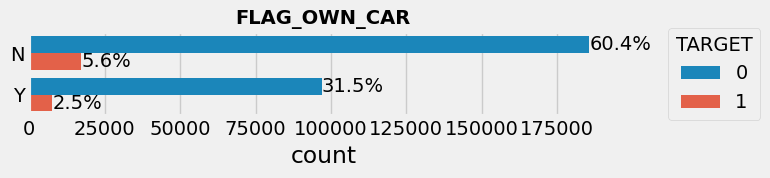

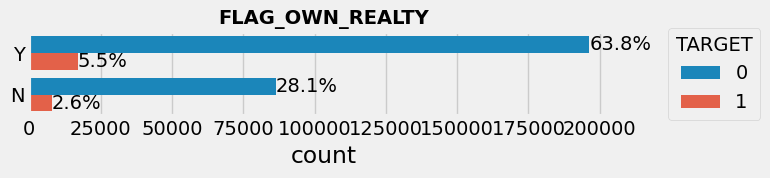

In [20]:
for col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
    plot_categorical_dist(
        application, col, hue="TARGET")


In [21]:
application.loc[(application["FLAG_OWN_CAR"]=="Y") & application["OWN_CAR_AGE"].isna(), assets].shape

(5, 3)

* Only ages of 5 cars owned are unknown.
* There is no realistic way to impute them more thoroughly than mean.
* At the same time, **car ownership and car age encode identical information**. Thus, Feature reduction would be required for a tree model.

!Servere outliers detected. Total values: 307511 original range: 0.0 - 91.0
Hiding outliers above 73.5: 2 values;


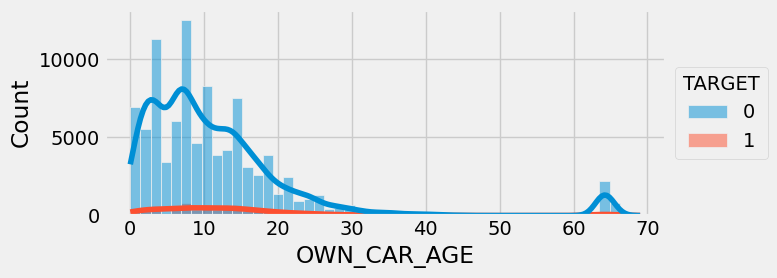

<Axes: xlabel='OWN_CAR_AGE', ylabel='Count'>

In [22]:
plot_numeric_dist(
    application, 'OWN_CAR_AGE', hue="TARGET")

* Cars are bimodally distributed. Likely difference between "everyday" and "collectors" cars.


#### Time-based features

In [23]:
time_features = [
    'DAYS_EMPLOYED',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'DAYS_LAST_PHONE_CHANGE',
    'HOUR_APPR_PROCESS_START'
]

application_columns['time_features'] = time_features
num_columns.update(time_features)

describer.describe(time_features)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
18,DAYS_EMPLOYED,How many days before the application the person started current employment,time only relative to the application,0,12574,int64,"[-637, -1188, -225]"
19,DAYS_REGISTRATION,How many days before the application did client change his registration,time only relative to the application,0,15688,float64,"[-3648.0, -1186.0, -4260.0]"
20,DAYS_ID_PUBLISH,How many days before the application did client change the identity document with which he applied for the loan,time only relative to the application,0,6168,int64,"[-2120, -291, -2531]"
33,HOUR_APPR_PROCESS_START,Approximately at what hour did the client apply for the loan,rounded,0,24,int64,"[10, 11, 9]"
95,DAYS_LAST_PHONE_CHANGE,How many days before application did client change phone,NaN,1,3773,float64,"[-1134.0, -828.0, -815.0]"


* No nan values observed, except for a single individual who has not changed their phone for a long while.

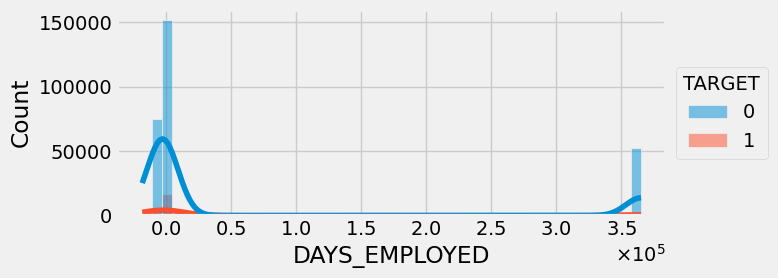

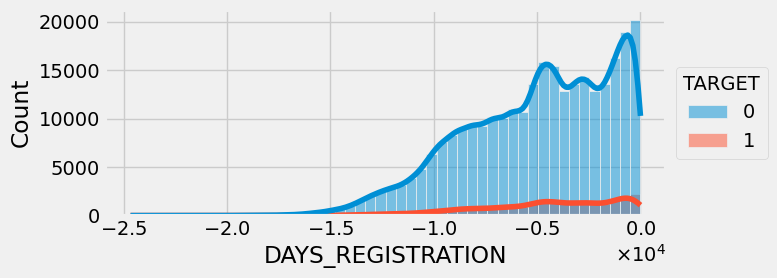

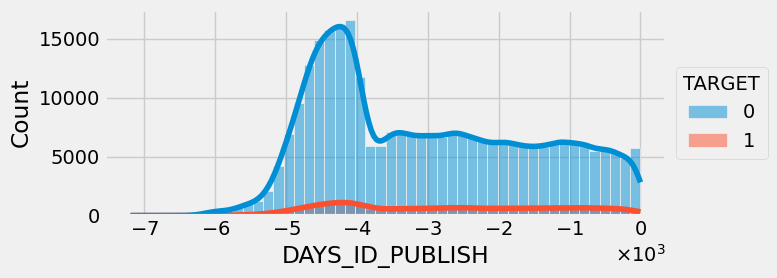

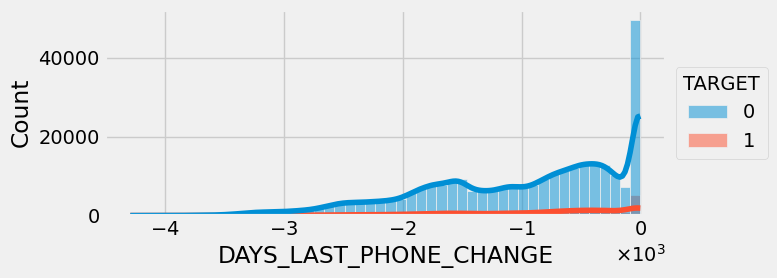

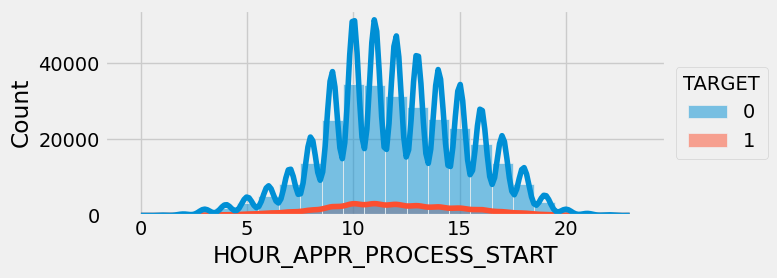

In [24]:
for col in time_features:
    plot_numeric_dist(
        application, col, hue="TARGET")

#### Contact information flags

In [25]:
contact_flags = [
    'FLAG_MOBIL',
    'FLAG_EMP_PHONE',
    'FLAG_WORK_PHONE',
    'FLAG_CONT_MOBILE',
    'FLAG_PHONE',
    'FLAG_EMAIL'
]

application_columns['contact_flags'] = contact_flags
bool_columns.update(contact_flags)

describer.describe(contact_flags)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
22,FLAG_MOBIL,"Did client provide mobile phone (1=YES, 0=NO)",NaN,0,2,int64,"[1, 0]"
23,FLAG_EMP_PHONE,"Did client provide work phone (1=YES, 0=NO)",NaN,0,2,int64,"[1, 0]"
24,FLAG_WORK_PHONE,"Did client provide home phone (1=YES, 0=NO)",NaN,0,2,int64,"[0, 1]"
25,FLAG_CONT_MOBILE,"Was mobile phone reachable (1=YES, 0=NO)",NaN,0,2,int64,"[1, 0]"
26,FLAG_PHONE,"Did client provide home phone (1=YES, 0=NO)",NaN,0,2,int64,"[1, 0]"
27,FLAG_EMAIL,"Did client provide email (1=YES, 0=NO)",NaN,0,2,int64,"[0, 1]"


* No missing values

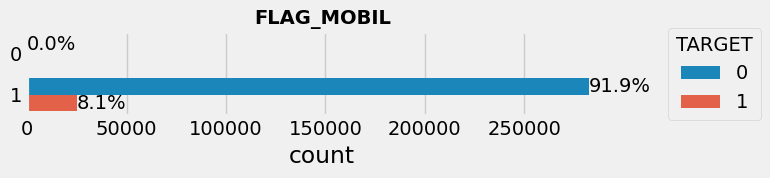

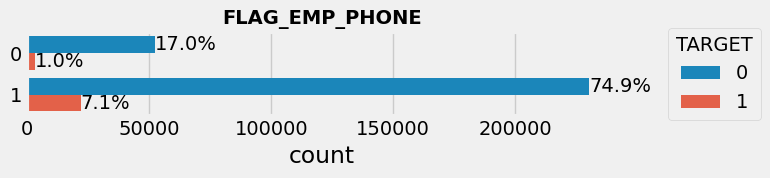

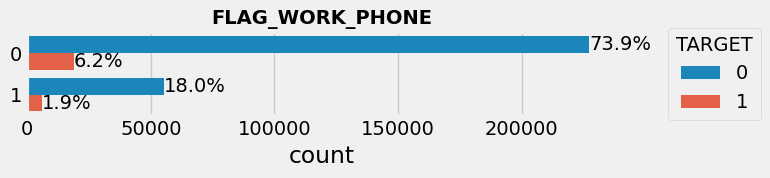

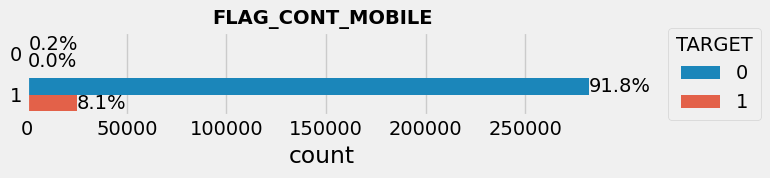

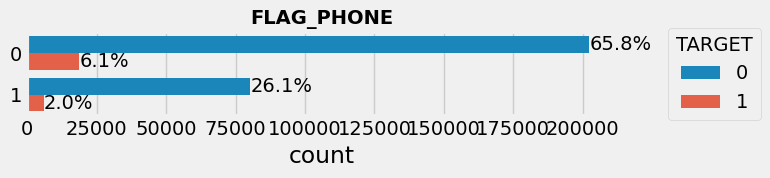

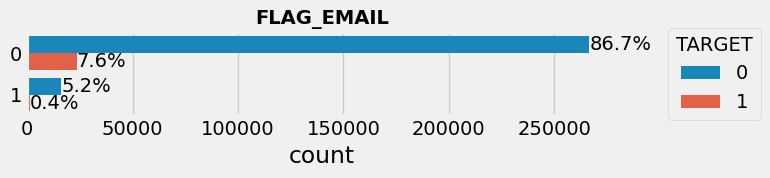

In [26]:
for col in contact_flags:
    plot_categorical_dist(
        application, col, hue="TARGET")

* Majority of individuals provided extensive personal details.

#### Demographics

In [27]:
demographics = [
    'CODE_GENDER',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'DAYS_BIRTH'
]

application_columns['demographics'] = demographics
cat_columns.update([
    'CODE_GENDER',
    'NAME_EDUCATION_TYPE','NAME_FAMILY_STATUS'])
num_columns.update(['CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_BIRTH'])


describer.describe(demographics)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
3,CODE_GENDER,Gender of the client,NaN,0,3,object,"[M, F, XNA]"
6,CNT_CHILDREN,Number of children the client has,NaN,0,15,int64,"[0, 1, 2]"
13,NAME_EDUCATION_TYPE,Level of highest education the client achieved,NaN,0,5,object,"[Secondary / secondary special, Higher education, Incomplete higher]"
14,NAME_FAMILY_STATUS,Family status of the client,NaN,0,6,object,"[Single / not married, Married, Civil marriage]"
17,DAYS_BIRTH,Client's age in days at the time of application,time only relative to the application,0,17460,int64,"[-9461, -16765, -19046]"
29,CNT_FAM_MEMBERS,How many family members does client have,NaN,2,17,float64,"[1.0, 2.0, 3.0]"


* Full information known
* Status of a few familly members is missing.

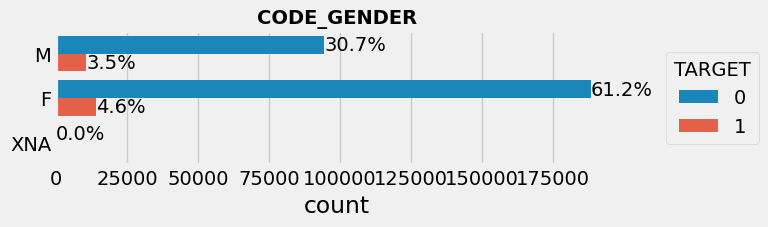

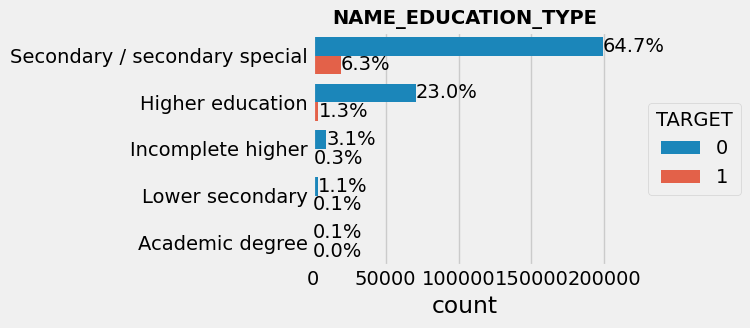

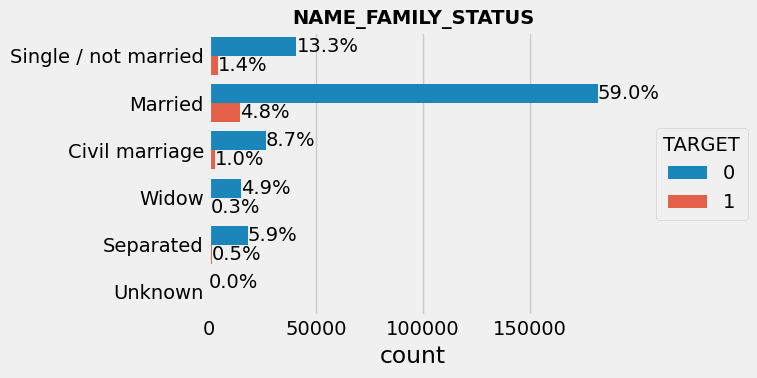

In [28]:
for col in ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']:
    plot_categorical_dist(
        application, col, hue="TARGET")

* Some familly status are unknown rather stored as nan. **This requires reassignment**

!Servere outliers detected. Total values: 307511 original range: 0 - 19
Hiding outliers above 5.0: 42 values;


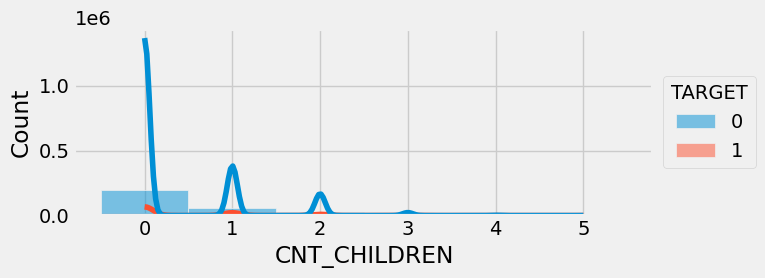

!Servere outliers detected. Total values: 307511 original range: 1.0 - 20.0
Hiding outliers above 8.5: 20 values;


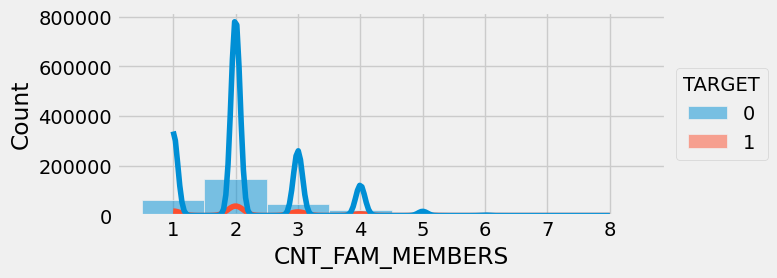

In [29]:
for col in ['CNT_CHILDREN', 'CNT_FAM_MEMBERS']:
    plot_numeric_dist(
        application, col, hue="TARGET")

In [30]:
top_cnt_children = application['CNT_CHILDREN'].value_counts().sort_index().head(20)
display(top_cnt_children)

top_cnt_fam_members = application['CNT_FAM_MEMBERS'].value_counts().sort_index().head(20)
display(top_cnt_fam_members)

CNT_CHILDREN
0     215371
1     61119 
2     26749 
3     3717  
4     429   
5     84    
6     21    
7     7     
8     2     
9     2     
10    2     
11    1     
12    2     
14    3     
19    2     
Name: count, dtype: int64

CNT_FAM_MEMBERS
1.0     67847 
2.0     158357
3.0     52601 
4.0     24697 
5.0     3478  
6.0     408   
7.0     81    
8.0     20    
9.0     6     
10.0    3     
11.0    1     
12.0    2     
13.0    1     
14.0    2     
15.0    1     
16.0    2     
20.0    2     
Name: count, dtype: int64

* Number of children can be approximated as a poisson distribution, thus the values can be considered valid.
* Once again, clipping (or normalisation), will be required for any model that takes magnitudes into account.


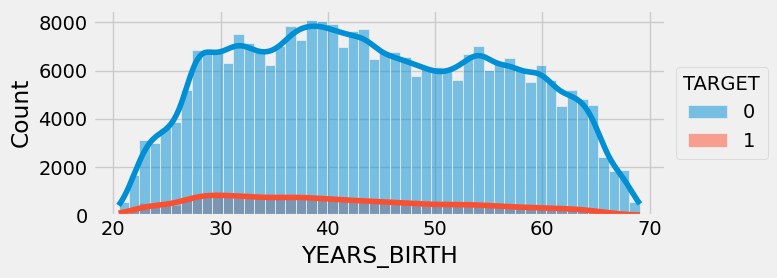

In [31]:
years_birth = (-application['DAYS_BIRTH'] / 365.25).round(1)

plot_numeric_dist(
    application.assign(YEARS_BIRTH=years_birth), 'YEARS_BIRTH', hue="TARGET");

* Only addults can apply to a mortage.
* **Converting age into years is not nescessary for ML solutions**, since the relative ordering is maintianed.

#### External sources

In [32]:
external_sources = [
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

application_columns['external_sources'] = external_sources
num_columns.update(external_sources)

describer.describe(external_sources)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
41,EXT_SOURCE_1,Normalized score from external data source,normalized,173378,114584,float64,"[0.0830369673913225, 0.3112673113812225, 0.7747614130547695]"
42,EXT_SOURCE_2,Normalized score from external data source,normalized,660,119831,float64,"[0.2629485927471776, 0.6222457752555098, 0.5559120833904428]"
43,EXT_SOURCE_3,Normalized score from external data source,normalized,60965,814,float64,"[0.1393757800997895, 0.7295666907060153, 0.6212263380626669]"


* Some external data source was used to give clients a rating.
* These are often missing. Assuming that they are calculated from current features, we could impute the values.
    * Otherwise, the EXT_SOURCE_1 has too many missing values to be meaningful.

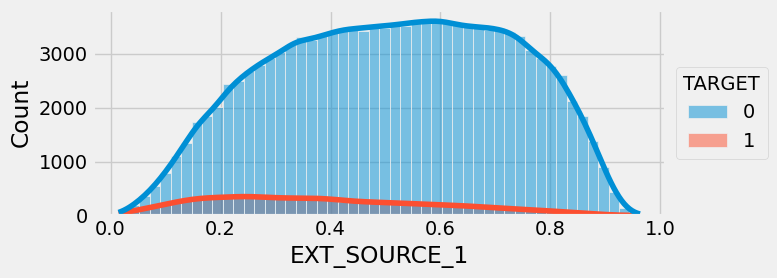

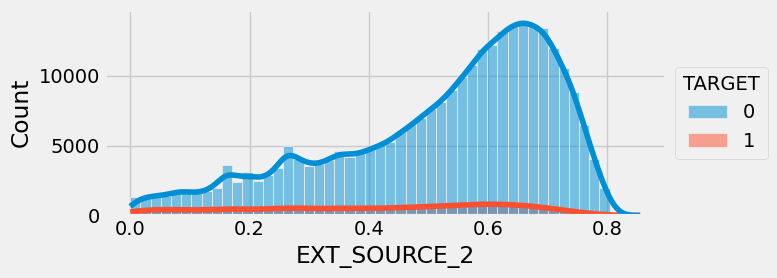

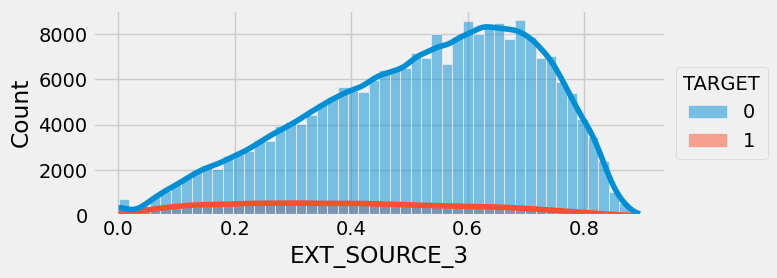

In [33]:
for col in external_sources:
    plot_numeric_dist(
        application, col, hue="TARGET")

The data takes various normal distributions and nicely fits in the range 0 to 1. It is likely that are more powerful technique than normalisation was used on less pretty data.

#### Location features

In [34]:
location_features = [
    "REGION_POPULATION_RELATIVE",
    "REG_REGION_NOT_LIVE_REGION",
    "REG_REGION_NOT_WORK_REGION",
    "LIVE_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_LIVE_CITY",
    "REG_CITY_NOT_WORK_CITY",
    "LIVE_CITY_NOT_WORK_CITY",
]

application_columns["location_features"] = location_features
num_columns.add(
    "REGION_POPULATION_RELATIVE",
)
bool_columns.update(location_features[1:])

describer.describe(location_features)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
16,REGION_POPULATION_RELATIVE,Normalized population of region where client lives (higher number means the client lives in more populated region),normalized,0,81,float64,"[0.018801, 0.0035409999999999, 0.010032]"
34,REG_REGION_NOT_LIVE_REGION,"Flag if client's permanent address does not match contact address (1=different, 0=same, at region level)",NaN,0,2,int64,"[0, 1]"
35,REG_REGION_NOT_WORK_REGION,"Flag if client's permanent address does not match work address (1=different, 0=same, at region level)",NaN,0,2,int64,"[0, 1]"
36,LIVE_REGION_NOT_WORK_REGION,"Flag if client's contact address does not match work address (1=different, 0=same, at region level)",NaN,0,2,int64,"[0, 1]"
37,REG_CITY_NOT_LIVE_CITY,"Flag if client's permanent address does not match contact address (1=different, 0=same, at city level)",NaN,0,2,int64,"[0, 1]"
38,REG_CITY_NOT_WORK_CITY,"Flag if client's permanent address does not match work address (1=different, 0=same, at city level)",NaN,0,2,int64,"[0, 1]"
39,LIVE_CITY_NOT_WORK_CITY,"Flag if client's contact address does not match work address (1=different, 0=same, at city level)",NaN,0,2,int64,"[0, 1]"


* Full location of each client is known.
* **A lof of location features are if statements based on each other**, thus they will likely yeald better to feature engineering.

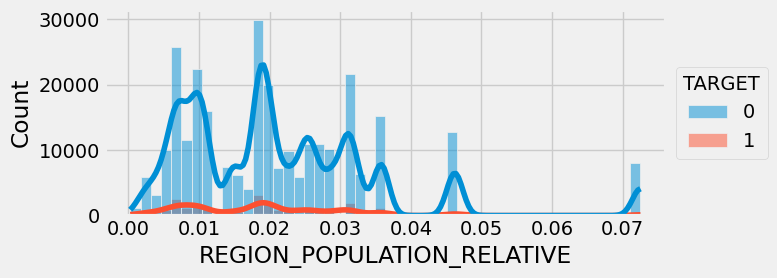

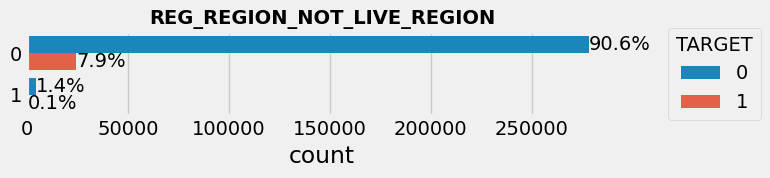

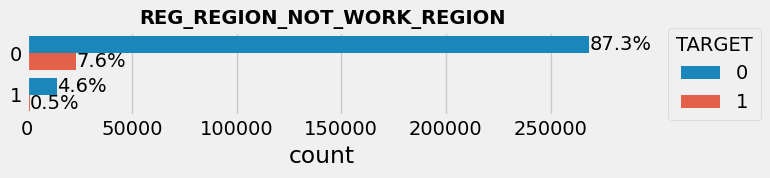

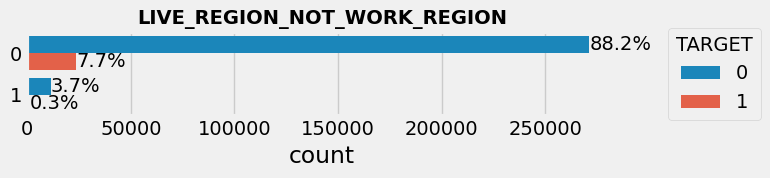

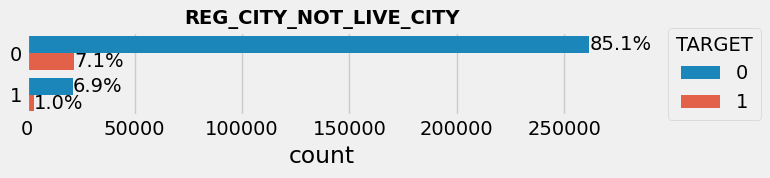

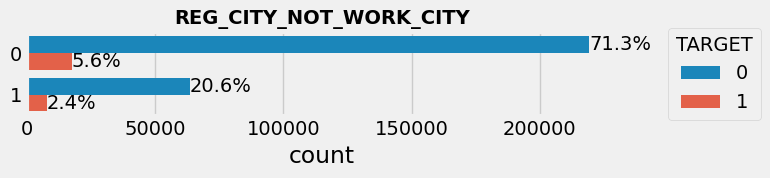

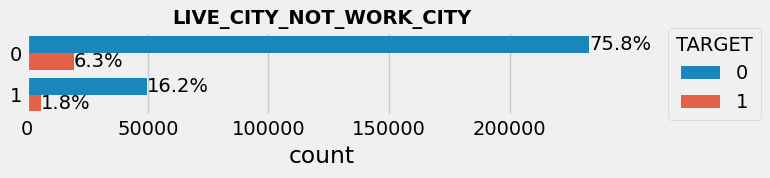

In [35]:
for col in ['REGION_POPULATION_RELATIVE']:
    plot_numeric_dist(
        application, col, hue="TARGET")

for col in ['REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 
           'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
           'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY']:
    plot_categorical_dist(
        application, col, hue="TARGET")

#### Social circle (mortage history)

In [36]:
social_circle = [
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE'
]

application_columns['social_circle'] = social_circle
num_columns.update(social_circle)

describer.describe(social_circle)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
91,OBS_30_CNT_SOCIAL_CIRCLE,How many observation of client's social surroundings with observable 30 DPD (days past due) default,NaN,1021,33,float64,"[2.0, 1.0, 0.0]"
92,DEF_30_CNT_SOCIAL_CIRCLE,How many observation of client's social surroundings defaulted on 30 DPD (days past due),NaN,1021,10,float64,"[2.0, 0.0, 1.0]"
93,OBS_60_CNT_SOCIAL_CIRCLE,How many observation of client's social surroundings with observable 60 DPD (days past due) default,NaN,1021,33,float64,"[2.0, 1.0, 0.0]"
94,DEF_60_CNT_SOCIAL_CIRCLE,How many observation of client's social surroundings defaulted on 60 (days past due) DPD,NaN,1021,9,float64,"[2.0, 0.0, 1.0]"


* Information ofobservation and defaulting on a loan within clients social surrounding are provided.
* Small portion of these values are missing.
    * **A ML sollution (e.g. N-neaserest neighbours) could be used to impute the missing values based on their location and socioeconomic status**

!Servere outliers detected. Total values: 307511 original range: 0.0 - 348.0
Hiding outliers above 15.0: 443 values;


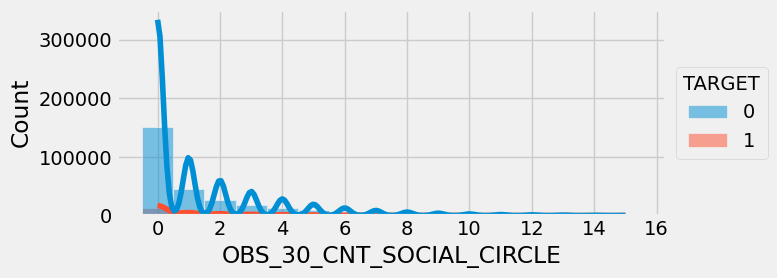

!Servere outliers detected. Total values: 307511 original range: 0.0 - 34.0
Hiding outliers above 2.5: 1515 values;


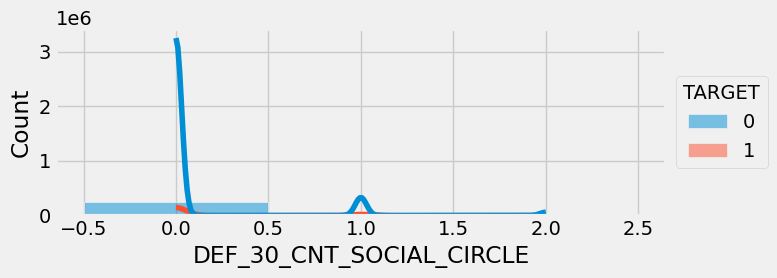

!Servere outliers detected. Total values: 307511 original range: 0.0 - 344.0
Hiding outliers above 15.0: 429 values;


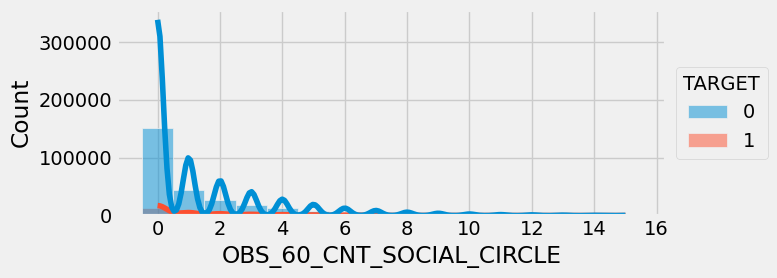

!Servere outliers detected. Total values: 307511 original range: 0.0 - 24.0
Hiding outliers above 2.5: 758 values;


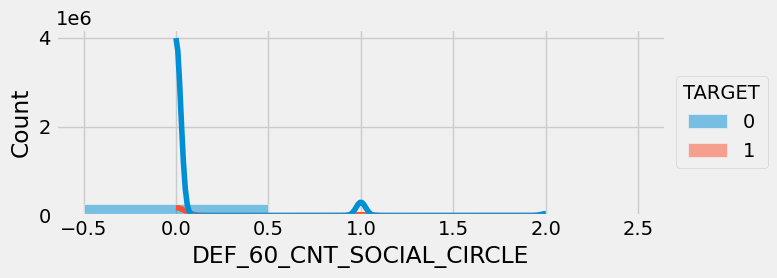

In [37]:
for col in social_circle:
    plot_numeric_dist(
        application, col, hue="TARGET")

#### Document flags

In [38]:
document_flags = [
    'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4',
    'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10',
    'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
    'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19',
    'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'
]

application_columns['document_flags'] = document_flags
bool_columns.update(document_flags)

describer.describe(document_flags)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
96,FLAG_DOCUMENT_2,Did client provide document 2,NaN,0,2,int64,"[0, 1]"
97,FLAG_DOCUMENT_3,Did client provide document 3,NaN,0,2,int64,"[1, 0]"
98,FLAG_DOCUMENT_4,Did client provide document 4,NaN,0,2,int64,"[0, 1]"
99,FLAG_DOCUMENT_5,Did client provide document 5,NaN,0,2,int64,"[0, 1]"
100,FLAG_DOCUMENT_6,Did client provide document 6,NaN,0,2,int64,"[0, 1]"
101,FLAG_DOCUMENT_7,Did client provide document 7,NaN,0,2,int64,"[0, 1]"
102,FLAG_DOCUMENT_8,Did client provide document 8,NaN,0,2,int64,"[0, 1]"
103,FLAG_DOCUMENT_9,Did client provide document 9,NaN,0,2,int64,"[0, 1]"
104,FLAG_DOCUMENT_10,Did client provide document 10,NaN,0,2,int64,"[0, 1]"
105,FLAG_DOCUMENT_11,Did client provide document 11,NaN,0,2,int64,"[0, 1]"


* There are no missing states in client providing documents for the application.

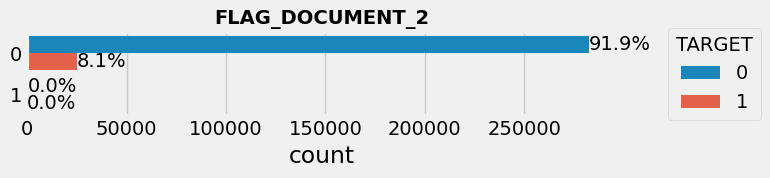

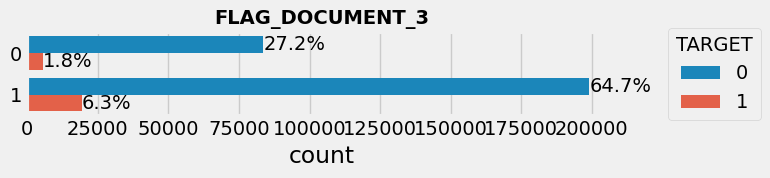

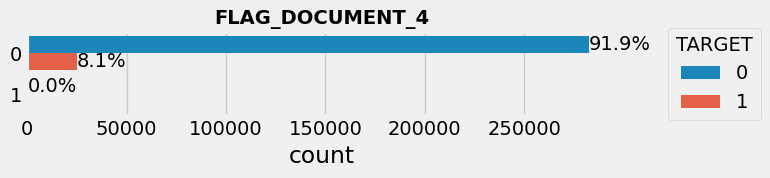

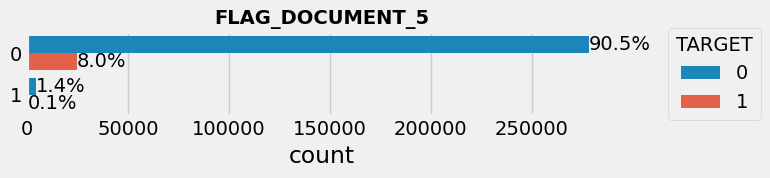

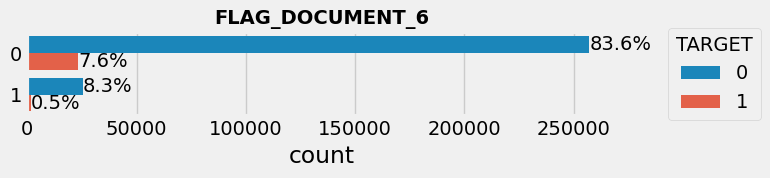

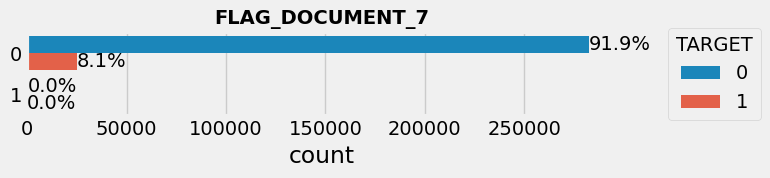

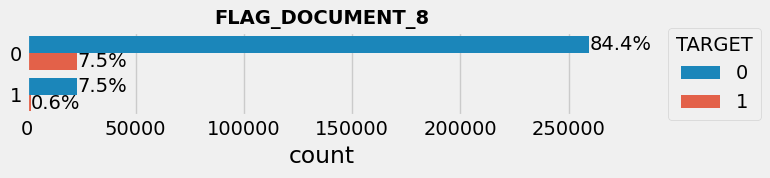

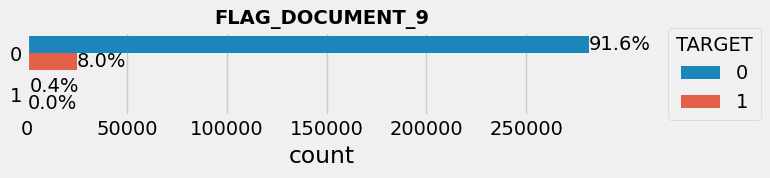

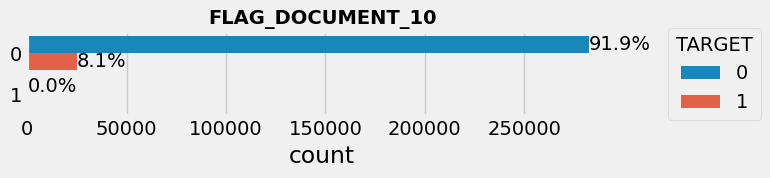

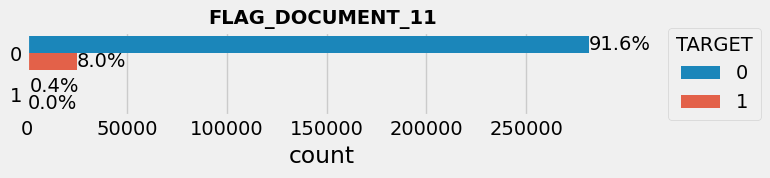

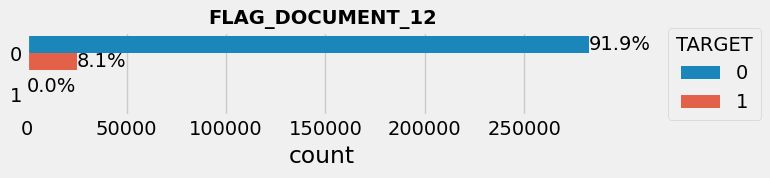

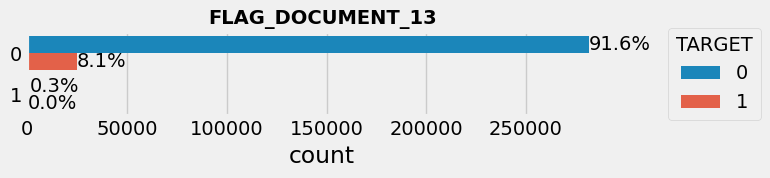

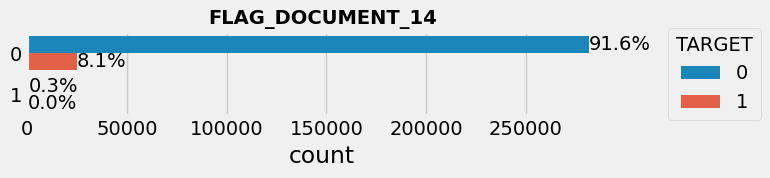

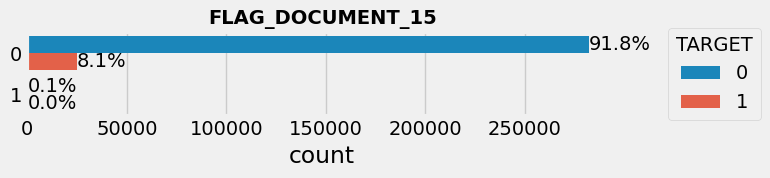

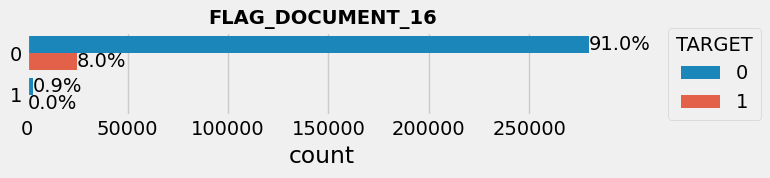

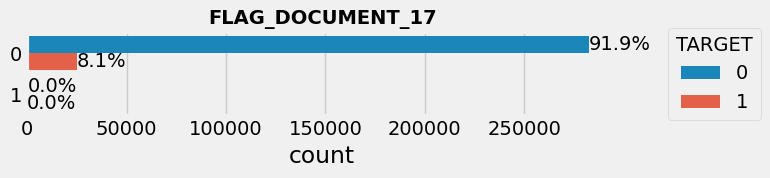

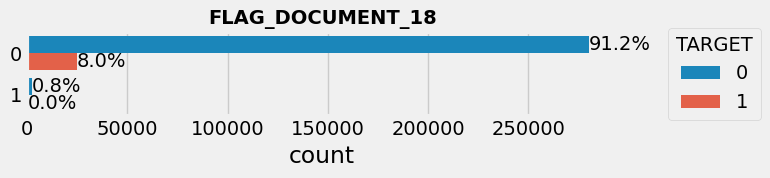

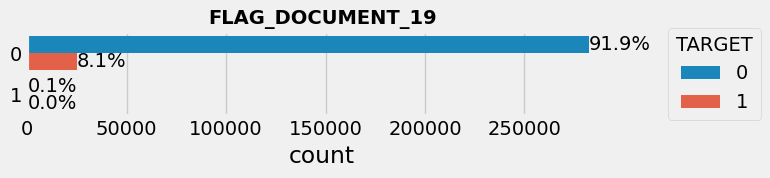

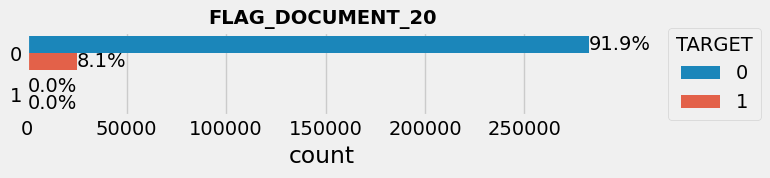

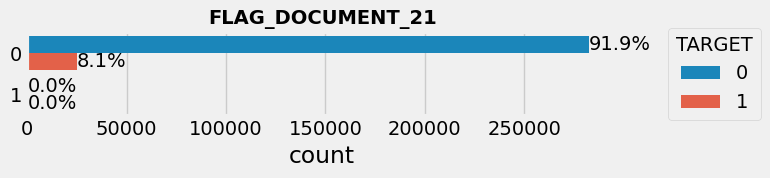

In [39]:
for col in document_flags:
    plot_categorical_dist(
        application, col, hue="TARGET")

* Some documents are always provided. **Applications might not proceed without provision of certain documents**, thus making them either a meaningless feature or a **requirement for application**.

#### Credit bureau enquiries

In [40]:
credit_bureau_enquiries = [
    'AMT_REQ_CREDIT_BUREAU_HOUR',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

application_columns['credit_bureau_enquiries'] = credit_bureau_enquiries
num_columns.update(credit_bureau_enquiries)

describer.describe(credit_bureau_enquiries)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
116,AMT_REQ_CREDIT_BUREAU_HOUR,Number of enquiries to Credit Bureau about the client one hour before application,NaN,41519,5,float64,"[0.0, 1.0, 2.0]"
117,AMT_REQ_CREDIT_BUREAU_DAY,Number of enquiries to Credit Bureau about the client one day before application (excluding one hour before application),NaN,41519,9,float64,"[0.0, 1.0, 3.0]"
118,AMT_REQ_CREDIT_BUREAU_WEEK,Number of enquiries to Credit Bureau about the client one week before application (excluding one day before application),NaN,41519,9,float64,"[0.0, 1.0, 3.0]"
119,AMT_REQ_CREDIT_BUREAU_MON,Number of enquiries to Credit Bureau about the client one month before application (excluding one week before application),NaN,41519,24,float64,"[0.0, 1.0, 2.0]"
120,AMT_REQ_CREDIT_BUREAU_QRT,Number of enquiries to Credit Bureau about the client 3 month before application (excluding one month before application),NaN,41519,11,float64,"[0.0, 1.0, 2.0]"
121,AMT_REQ_CREDIT_BUREAU_YEAR,Number of enquiries to Credit Bureau about the client one day year (excluding last 3 months before application),NaN,41519,25,float64,"[1.0, 0.0, 2.0]"


* Knowledge on inquiries to credit bureu is absent for a significant portion of clients.

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


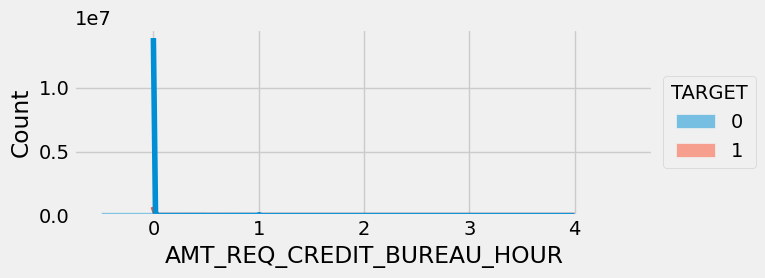

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


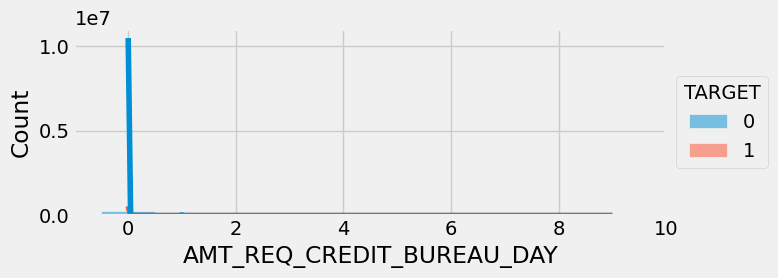

!Warning: low and high bounds are equal. This may indicate a constant or nearly constant series.


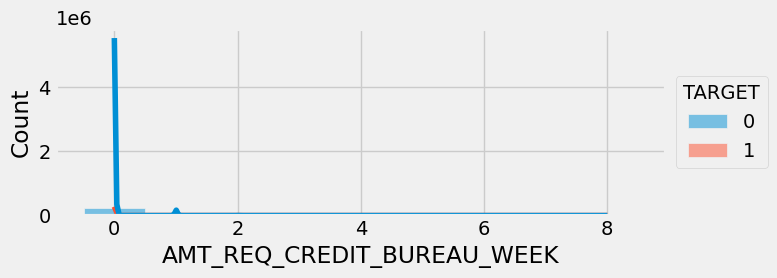

!Servere outliers detected. Total values: 307511 original range: 0.0 - 27.0
Hiding outliers above 2.5: 5226 values;


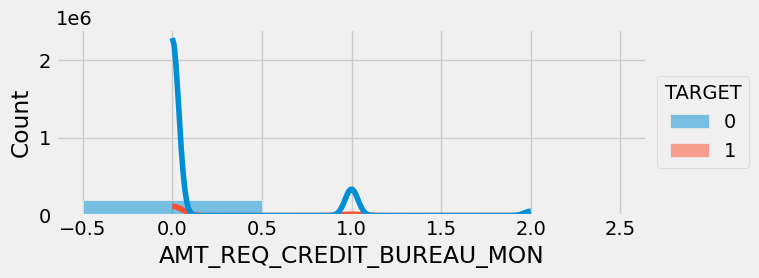

!Servere outliers detected. Total values: 307511 original range: 0.0 - 261.0
Hiding outliers above 5.0: 44 values;


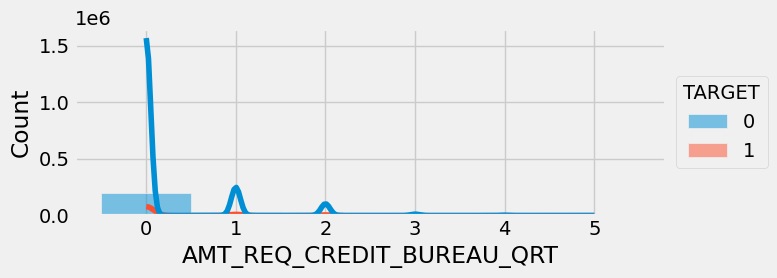

!Servere outliers detected. Total values: 307511 original range: 0.0 - 25.0
Hiding outliers above 15.0: 23 values;


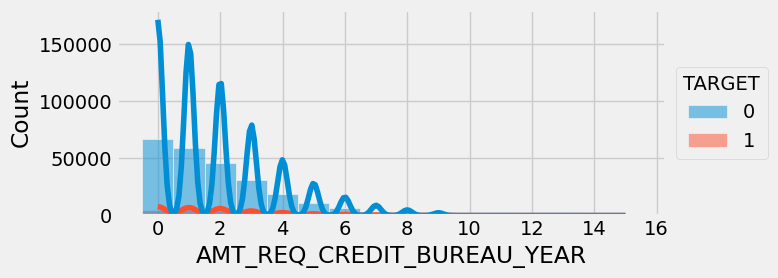

In [41]:
for col in credit_bureau_enquiries:
    plot_numeric_dist(
        application, col, hue="TARGET")

* All distributions are significantly right skewed.

#### Building features

In [42]:
building_properties = [
    'EMERGENCYSTATE_MODE',
    'FONDKAPREMONT_MODE',
    'WALLSMATERIAL_MODE',
    'HOUSETYPE_MODE'
]

application_columns['building_properties'] = building_properties
cat_columns.update(building_properties)


describer.describe(building_properties)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
86,FONDKAPREMONT_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,210295,4,object,"[reg oper account, org spec account, reg oper spec account]"
87,HOUSETYPE_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,154297,3,object,"[block of flats, terraced house, specific housing]"
89,WALLSMATERIAL_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,156341,7,object,"[Stone, brick, Block, Panel]"
90,EMERGENCYSTATE_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,145755,2,object,"[No, Yes]"


In [43]:
building_avg = [
    'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG',
    'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG',
    'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG',
    'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG'
]

application_columns['building_avg'] = building_avg
num_columns.update(building_avg)

describer.describe(building_avg)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
44,APARTMENTS_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,156061,2339,float64,"[0.0247, 0.0959, 0.0825]"
45,BASEMENTAREA_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,179943,3780,float64,"[0.0369, 0.0529, 0.0973]"
46,YEARS_BEGINEXPLUATATION_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,150007,285,float64,"[0.9722, 0.9851, 0.9811]"
47,YEARS_BUILD_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,204488,149,float64,"[0.6192, 0.7959999999999999, 0.7348]"
48,COMMONAREA_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,214865,3181,float64,"[0.0143, 0.0605, 0.0582]"
49,ELEVATORS_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,163891,257,float64,"[0.0, 0.08, 0.16]"
50,ENTRANCES_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,154828,285,float64,"[0.069, 0.0345, 0.2069]"
51,FLOORSMAX_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,153020,403,float64,"[0.0833, 0.2917, 0.1667]"
52,FLOORSMIN_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,208642,305,float64,"[0.125, 0.3333, 0.375]"
53,LANDAREA_AVG,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,182590,3527,float64,"[0.0369, 0.013, 0.0135]"


* Most information about patients living conditions are missing. Moreover, these are abstract normalized features.
    * This is a classification task onto itself, consequently, **unsupervised learning algorithm should be used aggregate this data**.

In [44]:
building_mode = [
    'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE',
    'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE',
    'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',
    'TOTALAREA_MODE'
]

application_columns['building_mode'] = building_mode
num_columns.update(building_mode)

describer.describe(building_mode)


from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
58,APARTMENTS_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,156061,760,float64,"[0.0252, 0.0924, 0.084]"
59,BASEMENTAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,179943,3841,float64,"[0.0383, 0.0538, 0.101]"
60,YEARS_BEGINEXPLUATATION_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,150007,221,float64,"[0.9722, 0.9851, 0.9811]"
61,YEARS_BUILD_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,204488,154,float64,"[0.6341, 0.804, 0.7452]"
62,COMMONAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,214865,3128,float64,"[0.0144, 0.0497, 0.0587]"
63,ELEVATORS_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,163891,26,float64,"[0.0, 0.0806, 0.1611]"
64,ENTRANCES_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,154828,30,float64,"[0.069, 0.0345, 0.2069]"
65,FLOORSMAX_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,153020,25,float64,"[0.0833, 0.2917, 0.1667]"
66,FLOORSMIN_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,208642,25,float64,"[0.125, 0.3333, 0.375]"
67,LANDAREA_MODE,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,182590,3563,float64,"[0.0377, 0.0128, 0.0138]"


In [45]:
building_medi = [
    'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI',
    'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI',
    'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI',
    'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI'
]

application_columns['building_medi'] = building_medi
num_columns.update(building_medi)

describer.describe(building_medi)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
72,APARTMENTS_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,156061,1148,float64,"[0.025, 0.0968, 0.0833]"
73,BASEMENTAREA_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,179943,3772,float64,"[0.0369, 0.0529, 0.0973]"
74,YEARS_BEGINEXPLUATATION_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,150007,245,float64,"[0.9722, 0.9851, 0.9811]"
75,YEARS_BUILD_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,204488,151,float64,"[0.6243, 0.7987, 0.7383]"
76,COMMONAREA_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,214865,3202,float64,"[0.0144, 0.0608, 0.0585]"
77,ELEVATORS_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,163891,46,float64,"[0.0, 0.08, 0.16]"
78,ENTRANCES_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,154828,46,float64,"[0.069, 0.0345, 0.2069]"
79,FLOORSMAX_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,153020,49,float64,"[0.0833, 0.2917, 0.1667]"
80,FLOORSMIN_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,208642,47,float64,"[0.125, 0.3333, 0.375]"
81,LANDAREA_MEDI,"Normalized information about building where the client lives, What is average (_AVG suffix), modus (_MODE suffix), median (_MEDI suffix) apartment size, common area, living area, age of building, number of elevators, number of entrances, state of the building, number of floor",normalized,182590,3560,float64,"[0.0375, 0.0132, 0.0137]"


* Identical to previous category, the number of missing values makes sense for unsupervised learning, but not using it as an unique feature.

#### Application process

In [46]:
application_process = [
    'NAME_TYPE_SUITE',
    'NAME_HOUSING_TYPE',
    'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY',
    'WEEKDAY_APPR_PROCESS_START',
    
]

application_columns['application_process'] = application_process
cat_columns.update([
    'NAME_TYPE_SUITE', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START',
])
num_columns.update([
    'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY'
])

describer.describe(application_process)

from tables:  ['application_train']


,Row,Description,Special,nan_n,unique_vals,dtype,sample_vals
11,NAME_TYPE_SUITE,Who was accompanying client when he was applying for the loan,NaN,1292,7,object,"[Unaccompanied, Family, Spouse, partner]"
15,NAME_HOUSING_TYPE,"What is the housing situation of the client (renting, living with parents, ...)",NaN,0,6,object,"[House / apartment, Rented apartment, With parents]"
30,REGION_RATING_CLIENT,"Our rating of the region where client lives (1,2,3)",NaN,0,3,int64,"[2, 1, 3]"
31,REGION_RATING_CLIENT_W_CITY,"Our rating of the region where client lives with taking city into account (1,2,3)",NaN,0,3,int64,"[2, 1, 3]"
32,WEEKDAY_APPR_PROCESS_START,On which day of the week did the client apply for the loan,NaN,0,7,object,"[WEDNESDAY, MONDAY, THURSDAY]"


* Client coming in alone or with others was not always marked.
* All other variables are present.
* A lot of these can be used as proxies for quality of life, however **region rating is rather questionable and should be investigated for VIF**.

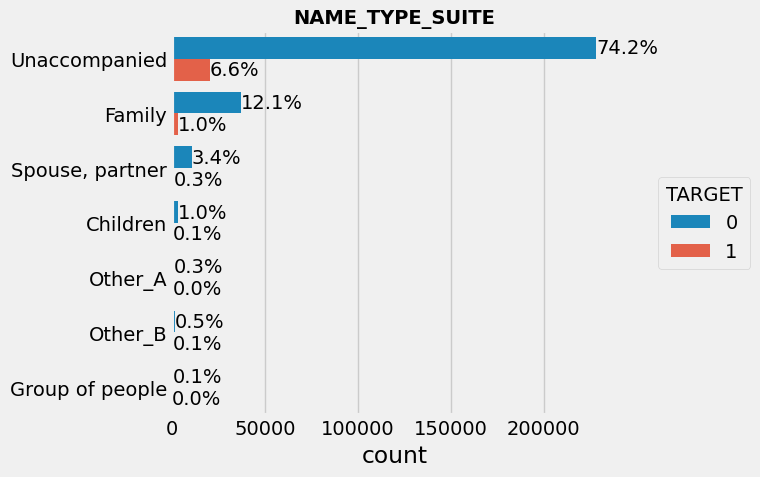

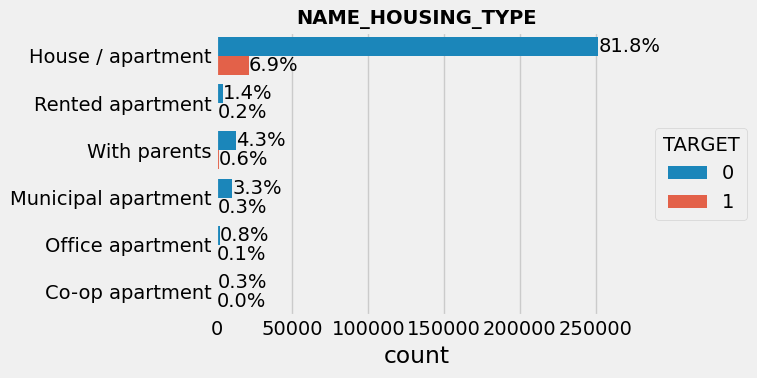

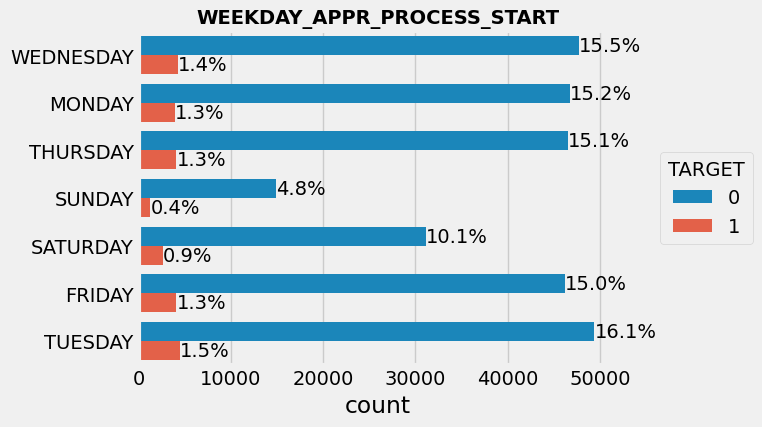

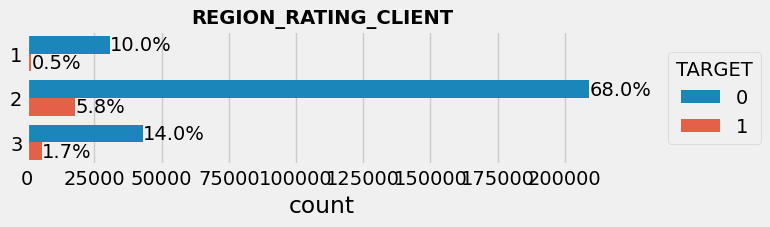

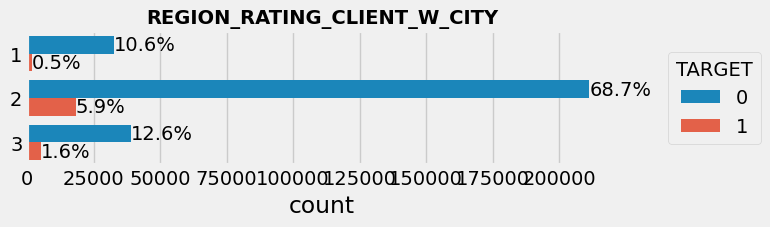

In [47]:
for col in ['NAME_TYPE_SUITE', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY']:
    plot_categorical_dist(
        application, col, hue="TARGET")


!Servere outliers detected. Total values: 307511 original range: 0.0 - 1.0
Hiding outliers above 0.8047: 316 values;


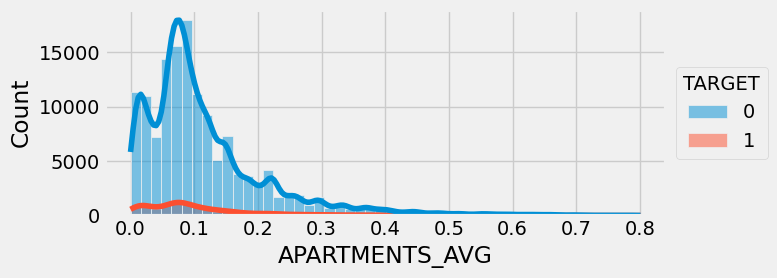

!Servere outliers detected. Total values: 307511 original range: 0.0 - 1.0
Hiding outliers above 0.78895: 402 values;


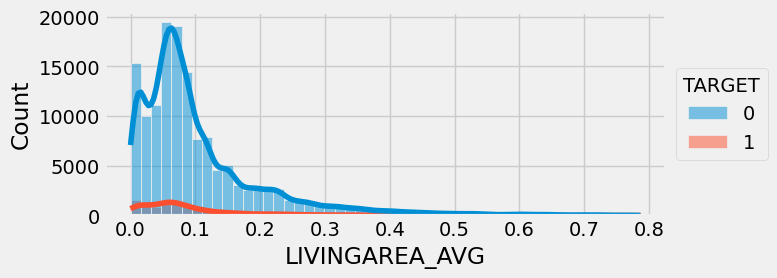

!Servere outliers detected. Total values: 307511 original range: 0.0 - 1.0
Hiding outliers above 0.9: 261 values;


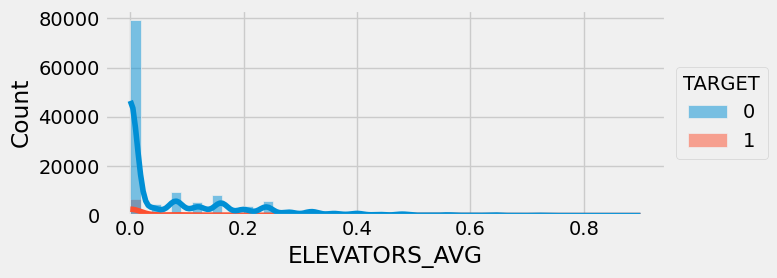

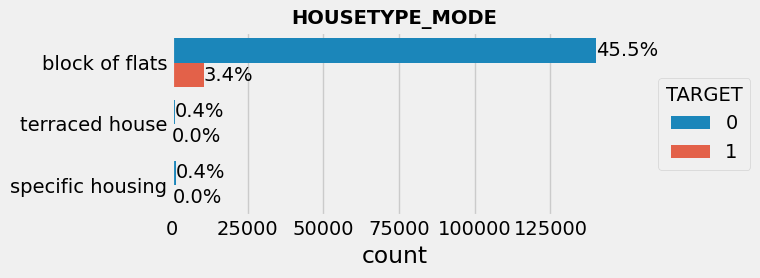

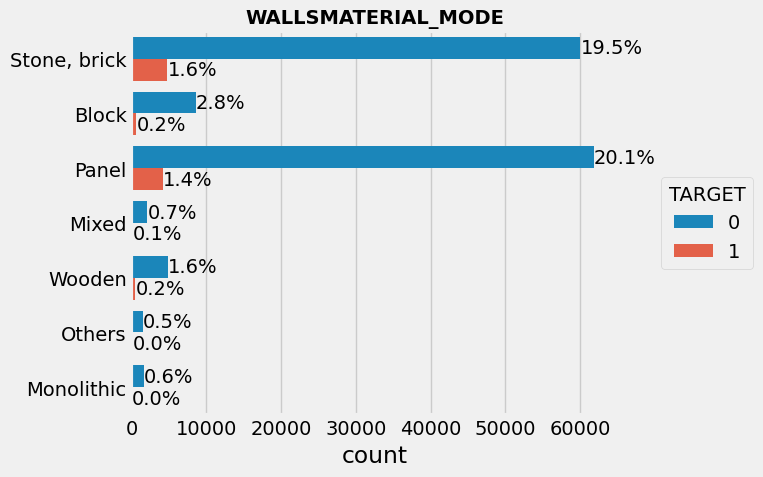

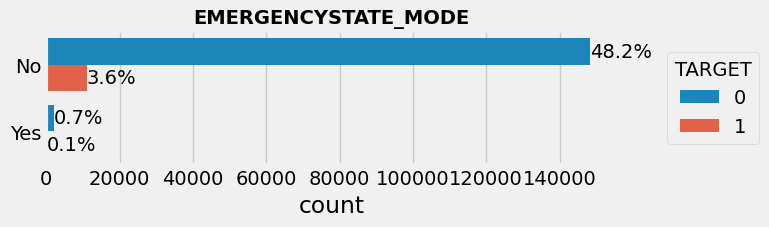

In [48]:
sample_building_avg = ['APARTMENTS_AVG', 'LIVINGAREA_AVG', 'ELEVATORS_AVG']
for col in sample_building_avg:
    plot_numeric_dist(
        application, col, hue="TARGET")

sample_building_mode = ['HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
for col in sample_building_mode:
    plot_categorical_dist(
        application, col, hue="TARGET")

## Application Conclusions

In [49]:
flattened_columns = []
for cols in application_columns.values():
    flattened_columns.extend(cols)
flattened_columns = set(flattened_columns)

print(f"Number of unique application columns in application_columns: {len(flattened_columns)}")
print("Missing columns:", set(descriptions[descriptions.Table =='application_data.csv'].Row).difference(flattened_columns))



Number of unique application columns in application_columns: 122
Missing columns: set()


In [50]:
na_counts = application.isna().sum()
print(na_counts[na_counts > 0].sort_values(ascending=False))

COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
                             ...  
EXT_SOURCE_2                660   
AMT_GOODS_PRICE             278   
AMT_ANNUITY                 12    
CNT_FAM_MEMBERS             2     
DAYS_LAST_PHONE_CHANGE      1     
Length: 67, dtype: int64


Total of 67 columns posses missing values. Imputing all these values manually is outside the scope of the project. Consequently, a ceratin subset of values will be imputed manually, whereas a nan-handling algorithm will need to be chosen.

Moreover, the variable structure and types are saved for further analysis.

In [51]:
with open('data/processed/application_columns.pkl', 'wb') as f:
    pkl.dump({
        'application_columns': application_columns,
        'non_feature_columns': non_feature_columns,
        'cat_columns': cat_columns,
        'num_columns': num_columns,
        'bool_columns': bool_columns,
        'str_columns': str_columns,
        'train_sk_id': application['SK_ID_CURR'].unique().tolist(),
        'test_sk_id': tables['application_test']['SK_ID_CURR'].unique().tolist()
    }, f)

# Application Actionables
Key insights derrived during data cleaning and investiation are listed here. Action is taken in further notebooks

#### Target Variable Analysis
- **Accuracy becomes near meaningless** due to highly imbalanced target variable
- Weighted metrics such as **f1_macro, Precision-Recall curve** will need to be used when training the model
- Affected columns: `TARGET`

#### Data processing
* Boolean values are encoded as `['Y', 'N']` and should be decoded to simplify model building.

#### Data Quality Issues
- **If missing occupations can be confirmedas outside the list, they should be assigned as "other"** - regarding missing occupation types for pensioners and other groups
- Affected columns: `OCCUPATION_TYPE`

#### Income Distribution
- **An outlier insensitive ML model should be used** 
- **Otherwise the outlier needs to be treated** - due to significantly right-skewed income distribution
- Affected columns: `AMT_INCOME_TOTAL`

#### Feature Engineering Opportunities
- **Car ownership and car age encode identical information** - Feature reduction would be required for a tree model
- **A lot of location features are if statements based on each other** - they will likely yield better to feature engineering
- **Converting age into years is not necessary for ML solutions** - since the relative ordering is maintained
- Affected columns: `FLAG_OWN_CAR`, `OWN_CAR_AGE`, `REG_REGION_NOT_LIVE_REGION`, `REG_REGION_NOT_WORK_REGION`, `LIVE_REGION_NOT_WORK_REGION`, `REG_CITY_NOT_LIVE_CITY`, `REG_CITY_NOT_WORK_CITY`, `LIVE_CITY_NOT_WORK_CITY`, `DAYS_BIRTH`

#### Data Imputation Strategies
- **This requires reassignment** - for family status that are unknown rather than stored as nan
- **A ML solution (e.g. N-nearest neighbours) could be used to impute the missing values based on their location and socioeconomic status** - for social circle data
- Affected columns: `NAME_FAMILY_STATUS`, `OBS_30_CNT_SOCIAL_CIRCLE`, `DEF_30_CNT_SOCIAL_CIRCLE`, `OBS_60_CNT_SOCIAL_CIRCLE`, `DEF_60_CNT_SOCIAL_CIRCLE`

#### Document Requirements
- **Applications might not proceed without provision of certain documents** - making them either a meaningless feature or a **requirement for application**
- Affected columns: `FLAG_DOCUMENT_2`, `FLAG_DOCUMENT_3`, `FLAG_DOCUMENT_4`, `FLAG_DOCUMENT_5`, `FLAG_DOCUMENT_6`, `FLAG_DOCUMENT_7`, `FLAG_DOCUMENT_8`, `FLAG_DOCUMENT_9`, `FLAG_DOCUMENT_10`, `FLAG_DOCUMENT_11`, `FLAG_DOCUMENT_12`, `FLAG_DOCUMENT_13`, `FLAG_DOCUMENT_14`, `FLAG_DOCUMENT_15`, `FLAG_DOCUMENT_16`, `FLAG_DOCUMENT_17`, `FLAG_DOCUMENT_18`, `FLAG_DOCUMENT_19`, `FLAG_DOCUMENT_20`, `FLAG_DOCUMENT_21`

#### Building Features Analysis
- **Unsupervised learning algorithm should be used to aggregate this data** - for building features which represent a classification task
- Affected columns: All building features (`APARTMENTS_AVG`, `BASEMENTAREA_AVG`, `YEARS_BEGINEXPLUATATION_AVG`, `YEARS_BUILD_AVG`, `COMMONAREA_AVG`, `ELEVATORS_AVG`, `ENTRANCES_AVG`, `FLOORSMAX_AVG`, `FLOORSMIN_AVG`, `LANDAREA_AVG`, `LIVINGAPARTMENTS_AVG`, `LIVINGAREA_AVG`, `NONLIVINGAPARTMENTS_AVG`, `NONLIVINGAREA_AVG`, `APARTMENTS_MODE`, `BASEMENTAREA_MODE`, `YEARS_BEGINEXPLUATATION_MODE`, `YEARS_BUILD_MODE`, `COMMONAREA_MODE`, `ELEVATORS_MODE`, `ENTRANCES_MODE`, `FLOORSMAX_MODE`, `FLOORSMIN_MODE`, `LANDAREA_MODE`, `LIVINGAPARTMENTS_MODE`, `LIVINGAREA_MODE`, `NONLIVINGAPARTMENTS_MODE`, `NONLIVINGAREA_MODE`, `FONDKAPREMONT_MODE`, `HOUSETYPE_MODE`, `TOTALAREA_MODE`, `WALLSMATERIAL_MODE`, `EMERGENCYSTATE_MODE`, `APARTMENTS_MEDI`, `BASEMENTAREA_MEDI`, `YEARS_BEGINEXPLUATATION_MEDI`, `YEARS_BUILD_MEDI`, `COMMONAREA_MEDI`, `ELEVATORS_MEDI`, `ENTRANCES_MEDI`, `FLOORSMAX_MEDI`, `FLOORSMIN_MEDI`, `LANDAREA_MEDI`, `LIVINGAPARTMENTS_MEDI`, `LIVINGAREA_MEDI`, `NONLIVINGAPARTMENTS_MEDI`, `NONLIVINGAREA_MEDI`)

#### Regional Rating Concerns
- **Region rating is rather questionable and should be investigated for VIF** - as proxies for quality of life
- Affected columns: `REGION_RATING_CLIENT`, `REGION_RATING_CLIENT_W_CITY`